# NPTEL — Foundations of R Software, Week 11
## Data Frames (recap), Data Import/Export, Descriptive Statistics, Graphics (Lectures 43, 46–49)



## Setup

In [ ]:
%load_ext rpy2.ipython

XML needs a system library to compile; `pyreadstat` lets us write a sample SPSS file. Both are quiet one-time installs.

In [ ]:
!apt-get -qq install -y libxml2-dev > /dev/null
%pip install -q pyreadstat

Create the stand-in data files used by the Lecture 46 examples (same contents as on the slides).

In [ ]:
import pandas as pd, pyreadstat

# Excel workbook: Sheet1 = Variable 1-3, Sheet2 = Variable 4-6, Sheet3 empty
s1 = pd.DataFrame({"Variable 1":[1,2,3,4,5], "Variable 2":[10,20,30,40,50], "Variable 3":[100,200,300,400,500]})
s2 = pd.DataFrame({"Variable 4":[6,7,8,9,10], "Variable 5":[110,120,130,140,150], "Variable 6":[110,210,310,410,510]})
with pd.ExcelWriter("/content/spexcel.xlsx") as w:
    s1.to_excel(w, sheet_name="Sheet1", index=False)
    s2.to_excel(w, sheet_name="Sheet2", index=False)
    pd.DataFrame().to_excel(w, sheet_name="Sheet3", index=False)

# SPSS file
pyreadstat.write_sav(pd.DataFrame({"id":[1,2,3], "score":[88.5,92.0,79.5], "group":[1,2,1]}), "/content/datafile.sav")

# HTML file with one table
open("/content/filename.html", "w").write("""<html><body><table>
<tr><th>name</th><th>marks</th></tr>
<tr><td>Asha</td><td>81</td></tr>
<tr><td>Ravi</td><td>67</td></tr>
<tr><td>Meena</td><td>92</td></tr>
</table></body></html>""")
print("files created")

files created


---
## Lecture 43 — Data Frames: Some More Operations (recap)

### 1. The `painters` data frame from package `MASS`

In [ ]:
%%R
library(MASS)
head(painters)

              Composition Drawing Colour Expression School
Da Udine               10       8     16          3      A
Da Vinci               15      16      4         14      A
Del Piombo              8      13     16          7      A
Del Sarto              12      16      9          8      A
Fr. Penni               0      15      8          0      A
Guilio Romano          15      16      4         14      A


### 2. `summary` on a categorical variable gives a frequency table

In [ ]:
%%R
summary(painters$School)

 A  B  C  D  E  F  G  H 
10  6  6 10  7  4  7  4 


### 3. `attach()` — use variable names directly

After `attach(painters)`, `Composition`, `Drawing`, `Colour`, `Expression` and `School` can be used without the `painters$` prefix.

In [ ]:
%%R
attach(painters)
summary(School)        # factor/character variable
summary(Composition)   # numeric variable

 A  B  C  D  E  F  G  H 
10  6  6 10  7  4  7  4 
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    8.25   12.50   11.56   15.00   18.00 


### 4. `detach()` restores the default — bare names stop working

In [ ]:
%%R
detach(painters)
summary(School)

Error: object 'School' not found 


### 5. `subset()` and the equivalent indexing form

In [ ]:
%%R
subset(painters, School=='F')                 # == is the logical equal sign
painters[ painters[["School"]] == "F", ]

           Composition Drawing Colour Expression School
Durer                8      10     10          8      F
Holbein              9      10     16         13      F
Pourbus              4      15      6          6      F
Van Leyden           8       6      6          4      F
           Composition Drawing Colour Expression School
Durer                8      10     10          8      F
Holbein              9      10     16         13      F
Pourbus              4      15      6          6      F
Van Leyden           8       6      6          4      F


### 6. Subsetting on a numeric condition

In [ ]:
%%R
subset(painters, Composition <= 6)

              Composition Drawing Colour Expression School
Fr. Penni               0      15      8          0      A
Perugino                4      12     10          4      A
Bassano                 6       8     17          0      D
Bellini                 4       6     14          0      D
Murillo                 6       8     15          4      D
Palma Vecchio           5       6     16          0      D
Caravaggio              6       6     16          0      E
Pourbus                 4      15      6          6      F


### 7. Dropping uninteresting columns with `select`

In [ ]:
%%R
subset(painters, School=="F", select=c(-3,-5))   # drops Colour and School

           Composition Drawing Expression
Durer                8      10          8
Holbein              9      10         13
Pourbus              4      15          6
Van Leyden           8       6          4


### 8. `split` partitions the data by a factor; each piece is a data frame

In [ ]:
%%R
splitted = split(painters, painters$School)
splitted
is.data.frame(splitted$A)

$A
                Composition Drawing Colour Expression School
Da Udine                 10       8     16          3      A
Da Vinci                 15      16      4         14      A
Del Piombo                8      13     16          7      A
Del Sarto                12      16      9          8      A
Fr. Penni                 0      15      8          0      A
Guilio Romano            15      16      4         14      A
Michelangelo              8      17      4          8      A
Perino del Vaga          15      16      7          6      A
Perugino                  4      12     10          4      A
Raphael                  17      18     12         18      A

$B
             Composition Drawing Colour Expression School
F. Zucarro            10      13      8          8      B
Fr. Salviata          13      15      8          8      B
Parmigiano            10      15      6          6      B
Primaticcio           15      14      7         10      B
T. Zucarro            13      14

---
## Lecture 46 — Data Handling: Importing Excel and Other Files

The slides use `setwd("C:/RCourse/")` (a Windows path). In Colab the working folder is `/content`.

### 9. Install and load `readxl`

One-time install, takes a minute or two and prints compile logs, so no output is shown here.

In [ ]:
%%R
install.packages("readxl", repos="https://cloud.r-project.org")
library(readxl)

### 10. Reading a sheet — `read_excel("file", sheet=)`

`spexcel.xlsx` (made in Cell 3) has the layout from the slide: Sheet1 holds Variable 1-3, Sheet2 holds Variable 4-6.

In [ ]:
%%R
setwd("/content")
library(readxl)
dataspexcel = read_excel("spexcel.xlsx", sheet=1)
dataspexcel

# A tibble: 5 × 3
  `Variable 1` `Variable 2` `Variable 3`
         <dbl>        <dbl>        <dbl>
1            1           10          100
2            2           20          200
3            3           30          300
4            4           40          400
5            5           50          500


### 11. Extracting a variable with `$` (backticks because of the space in the name)

In [ ]:
%%R
dataspexcel$`Variable 1`
dataspexcel$`Variable 2`
mean(dataspexcel$`Variable 1`)

[1] 1 2 3 4 5
[1] 10 20 30 40 50
[1] 3


### 12. Second sheet

In [ ]:
%%R
dataspexcel2 = read_excel("spexcel.xlsx", sheet=2)
dataspexcel2
dataspexcel2$`Variable 4`
dataspexcel2$`Variable 5`
dataspexcel2$`Variable 6`
mean(dataspexcel2$`Variable 6`)

# A tibble: 5 × 3
  `Variable 4` `Variable 5` `Variable 6`
         <dbl>        <dbl>        <dbl>
1            6          110          110
2            7          120          210
3            8          130          310
4            9          140          410
5           10          150          510
[1]  6  7  8  9 10
[1] 110 120 130 140 150
[1] 110 210 310 410 510
[1] 310


### 13. Limit the rows read with `n_max`

In [ ]:
%%R
dataspexcel4 = read_excel("spexcel.xlsx", n_max=3)
dataspexcel4

# A tibble: 3 × 3
  `Variable 1` `Variable 2` `Variable 3`
         <dbl>        <dbl>        <dbl>
1            1           10          100
2            2           20          200
3            3           30          300


### 14. Read a cell range with `range=` (A1 notation)

Because the first row of the range is used as the header, the first data row becomes the column names — exactly as the slide shows.

In [ ]:
%%R
dataspexcel5 = read_excel("spexcel.xlsx", range="A2:B3", sheet=1)
dataspexcel5
dataspexcel6 = read_excel("spexcel.xlsx", range="A2:B3", sheet=2)
dataspexcel6

# A tibble: 1 × 2
    `1`  `10`
  <dbl> <dbl>
1     2    20
# A tibble: 1 × 2
    `6` `110`
  <dbl> <dbl>
1     7   120


### 15. The same range in R1C1 notation

R1C1 = Row-Column notation, so `R2C3` is the cell in the 2nd row, 3rd column. (The slide gave this form as a template without output.)

In [ ]:
%%R
read_excel("spexcel.xlsx", range="R1C2:R2C5", sheet=1)

# A tibble: 1 × 4
  `Variable 2` `Variable 3` ...3  ...4 
         <dbl>        <dbl> <lgl> <lgl>
1           10          100 NA    NA   


New names:
• `` -> `...3`
• `` -> `...4`


### 16. SPSS files — `foreign::read.spss()`

`datafile.sav` is a small stand-in file made in Cell 3.

In [ ]:
%%R
# install.packages("foreign")   # already bundled with R
library(foreign)
data = read.spss("datafile.sav", to.data.frame=TRUE)
data

  id score group
1  1  88.5     1
2  2  92.0     2
3  3  79.5     1


### 17. HTML tables — `XML::readHTMLTable()`

`filename.html` is a small stand-in file made in Cell 3. One-time install of `XML` first (no output shown).

In [ ]:
%%R
install.packages("XML", repos="https://cloud.r-project.org")

In [ ]:
%%R
library(XML)
data = readHTMLTable("filename.html")
data

$`NULL`
   name marks
1  Asha    81
2  Ravi    67
3 Meena    92


### 18. Other formats from the `foreign` package

The slide lists these four readers (they need files from the other software, so only the signatures are shown):

| Function | Format |
|---|---|
| `read.octave("<path>")` | Octave / MATLAB |
| `read.systat("<path>")` | SYSTAT |
| `read.xport("<path>")` | SAS XPORT |
| `read.dta("<path>")` | Stata |

`write.dta()` lets us demo one of them end-to-end:

In [ ]:
%%R
library(foreign)
write.dta(data.frame(a=1:3, b=c(2.5, 3.5, 4.5)), "demo.dta")
read.dta("demo.dta")

  a   b
1 1 2.5
2 2 3.5
3 3 4.5


---
## Lecture 47 — Saving and Writing Data Files

`write(x, file = "data", ncolumns, append = FALSE, sep = " ")` writes an atomic vector to a file. The default `ncolumns` is 5 for numbers, which is why the file has 5 values per line.

### 19. `write()` a vector, then look at the file

In [ ]:
%%R
x = c(1:100)
x
write(x, file="shalabh")
cat(readLines("shalabh"), sep="\n")

  [1]   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
 [19]  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
 [37]  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
 [55]  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
 [73]  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
 [91]  91  92  93  94  95  96  97  98  99 100
1 2 3 4 5
6 7 8 9 10
11 12 13 14 15
16 17 18 19 20
21 22 23 24 25
26 27 28 29 30
31 32 33 34 35
36 37 38 39 40
41 42 43 44 45
46 47 48 49 50
51 52 53 54 55
56 57 58 59 60
61 62 63 64 65
66 67 68 69 70
71 72 73 74 75
76 77 78 79 80
81 82 83 84 85
86 87 88 89 90
91 92 93 94 95
96 97 98 99 100


### 20. `write.csv()` — comma-separated output

The slide gives only the usage; here it is on a small data frame. `sep` and `col.names` are fixed by `write.csv`.

In [ ]:
%%R
df1 = data.frame(state=c("UP", "MP", "AP", "JK"),
                 popnsize=c(1000,2000,3000,4000))
write.csv(df1, file="df1.csv")
cat(readLines("df1.csv"), sep="\n")

# row.names=FALSE drops the row-number column
write.csv(df1, file="df1_norow.csv", row.names=FALSE)
cat(readLines("df1_norow.csv"), sep="\n")

"","state","popnsize"
"1","UP",1000
"2","MP",2000
"3","AP",3000
"4","JK",4000
"state","popnsize"
"UP",1000
"MP",2000
"AP",3000
"JK",4000


### 21. `write.table()` — the general version (choose `sep`, `quote`, `na`)

In [ ]:
%%R
write.table(df1, file="df1.txt", sep="\t", quote=FALSE, row.names=FALSE)
cat(readLines("df1.txt"), sep="\n")

# file="" prints to the console
write.table(df1, file="", sep=" ", quote=TRUE)

state	popnsize
UP	1000
MP	2000
AP	3000
JK	4000
"state" "popnsize"
"1" "UP" 1000
"2" "MP" 2000
"3" "AP" 3000
"4" "JK" 4000


---
## Lecture 48 — Descriptive Statistics: Frequencies and Partition Values

### 22. Coding 10 persons: 1 = male (M), 2 = female (F)

M, F, M, F, M, M, M, F, M, M

In [ ]:
%%R
gender <- c(1, 2, 1, 2, 1, 1, 1, 2, 1, 1)
gender

 [1] 1 2 1 2 1 1 1 2 1 1


### 23. Absolute and relative frequencies with `table()`

In [ ]:
%%R
gender <- c(1, 2, 1, 2, 1, 1, 1, 2, 1, 1)
table(gender)                   # Absolute frequencies
table(gender)/length(gender)    # Relative frequencies

gender
1 2 
7 3 
gender
  1   2 
0.7 0.3 


### 24. Pizza delivery data — three branches (1 = East, 2 = West, 3 = Central)

The 100 recorded values of `direction`:

In [ ]:
%%R
direction = c(1,1,2,1,2,3,2,2,3,3,3,1,2,3,2,2,3,1,1,3,3,1,2,1,3,3,3,2,2,2,2,1,2,2,1,1,1,3,2,2,1,2,3,2,2,1,2,3,3,2,1,2,2,3,1,1,2,1,2,3,2,3,2,2,3,1,2,3,3,3,2,1,1,1,2,1,1,2,1,2,3,3,1,2,3,3,2,1,2,3,2,1,3,2,2,2,2,3,2,2)
direction
table(direction)                      # Absolute frequencies
table(direction)/length(direction)    # Relative frequencies

  [1] 1 1 2 1 2 3 2 2 3 3 3 1 2 3 2 2 3 1 1 3 3 1 2 1 3 3 3 2 2 2 2 1 2 2 1 1 1
 [38] 3 2 2 1 2 3 2 2 1 2 3 3 2 1 2 2 3 1 1 2 1 2 3 2 3 2 2 3 1 2 3 3 3 2 1 1 1
 [75] 2 1 1 2 1 2 3 3 1 2 3 3 2 1 2 3 2 1 3 2 2 2 2 3 2 2
direction
 1  2  3 
28 43 29 
direction
   1    2    3 
0.28 0.43 0.29 


### 25. Partition values with `quantile()`

Quartiles split the data into 4 equal parts, deciles into 10, percentiles into 100. Marks of 15 students:

In [ ]:
%%R
marks = c(68, 82, 63, 86, 34, 96, 41, 89, 29, 51, 75, 77, 56, 59, 42)
marks
quantile(marks)                                  # default: quartiles
quantile(marks, probs=c(0, 0.25, 0.5, 0.75, 1))  # same, probabilities spelled out

 [1] 68 82 63 86 34 96 41 89 29 51 75 77 56 59 42
  0%  25%  50%  75% 100% 
29.0 46.5 63.0 79.5 96.0 
  0%  25%  50%  75% 100% 
29.0 46.5 63.0 79.5 96.0 


### 26. Choosing your own probabilities

In [ ]:
%%R
marks = c(68, 82, 63, 86, 34, 96, 41, 89, 29, 51, 75, 77, 56, 59, 42)
quantile(marks, probs=c(0, 0.20, 0.4, 0.6, 0.8, 1))

  0%  20%  40%  60%  80% 100% 
29.0 41.8 57.8 70.8 82.8 96.0 


---
## Lecture 49 — Graphics: Scatter Plot and Bar Plots

### 27. Scatter plot — `plot(x)` for one variable

Heights (cm) of 50 persons.

[1] 50


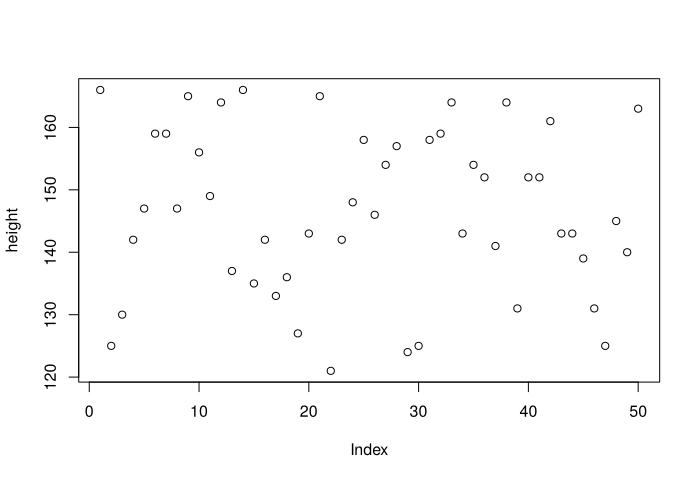

In [ ]:
%%R
height = c(166,125,130,142,147,159,159,147,165,156,149,164,137,166,135,142,133,136,127,143,165,121,142,148,158,146,154,157,124,125,158,159,164,143,154,152,141,164,131,152,152,161,143,143,139,131,125,145,140,163)
length(height)
plot(height)

### 28. Adding colour

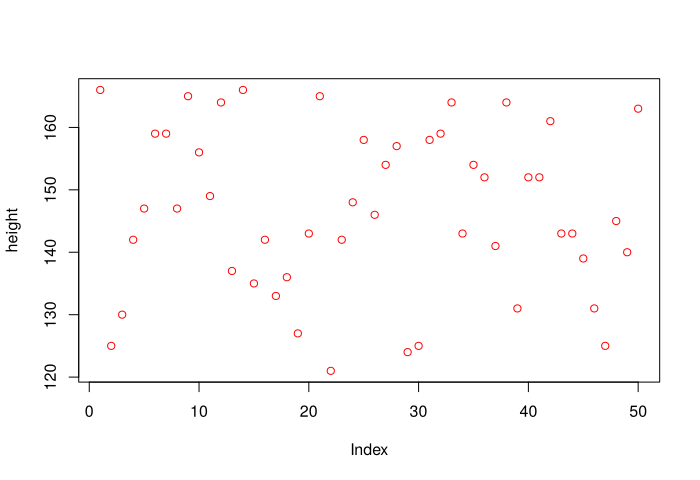

In [ ]:
%%R
plot(height, col = "red")

### 29. Bar plots — only for categorical variables

`barplot(x)` plots the *values* of `x`, which is rarely what you want for coded data:

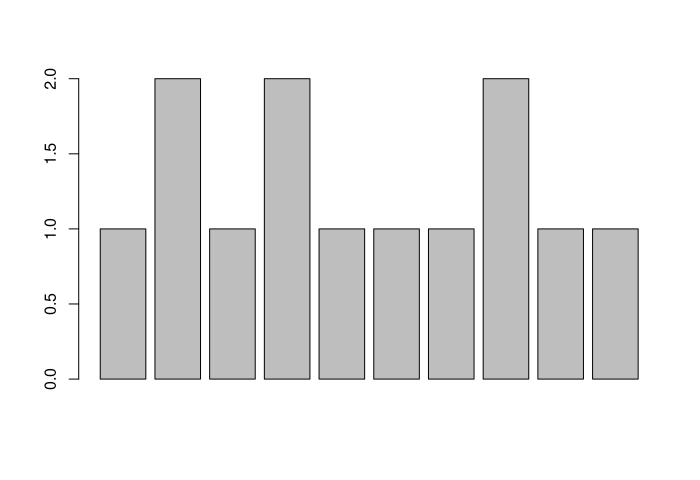

In [ ]:
%%R
gender = c(1, 2, 1, 2, 1, 1, 1, 2, 1, 1)
barplot(gender)   # Do you want this?

### 30. `barplot(table(x))` — absolute frequencies

gender
1 2 
7 3 


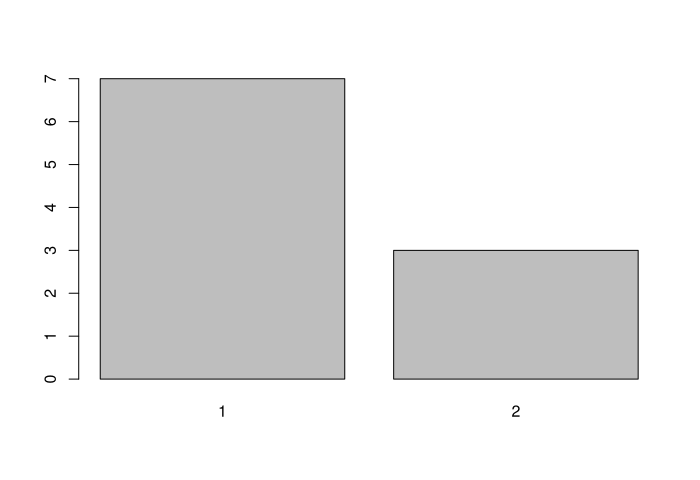

In [ ]:
%%R
table(gender)
barplot(table(gender))

### 31. Relative frequencies

gender
  1   2 
0.7 0.3 


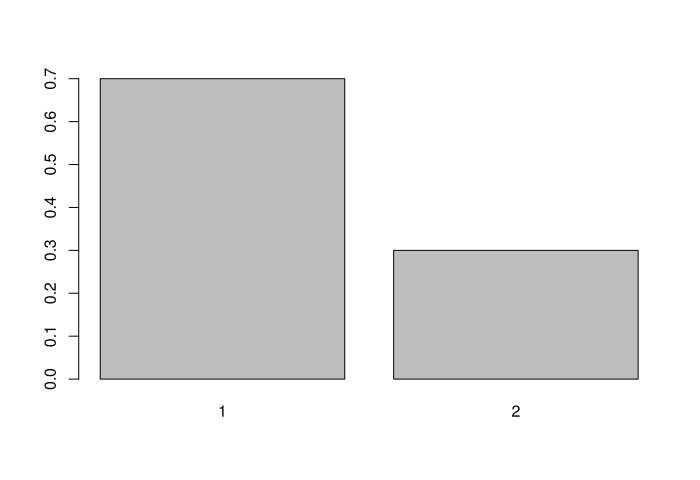

In [ ]:
%%R
table(gender)/length(gender)
barplot(table(gender)/length(gender))

### 32. The pizza delivery data — wrong way, then the right way

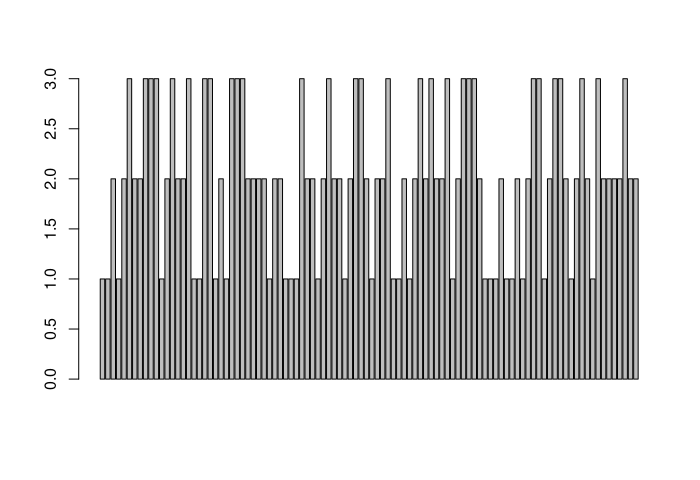

In [ ]:
%%R
direction = c(1,1,2,1,2,3,2,2,3,3,3,1,2,3,2,2,3,1,1,3,3,1,2,1,3,3,3,2,2,2,2,1,2,2,1,1,1,3,2,2,1,2,3,2,2,1,2,3,3,2,1,2,2,3,1,1,2,1,2,3,2,3,2,2,3,1,2,3,3,3,2,1,1,1,2,1,1,2,1,2,3,3,1,2,3,3,2,1,2,3,2,1,3,2,2,2,2,3,2,2)
barplot(direction)   # Do you want this?

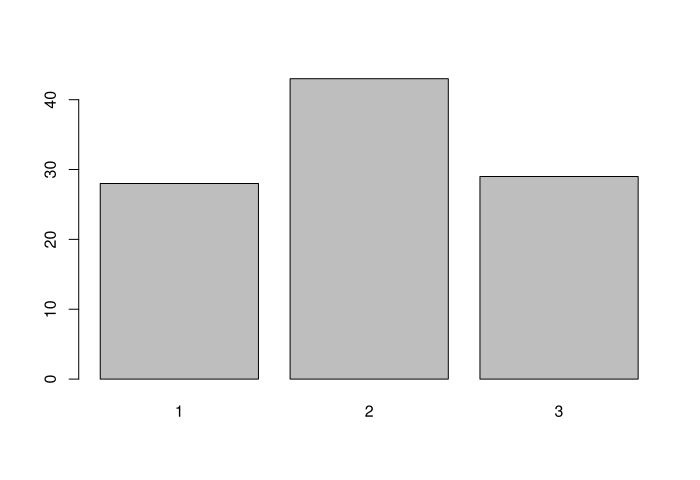

In [ ]:
%%R
barplot(table(direction))

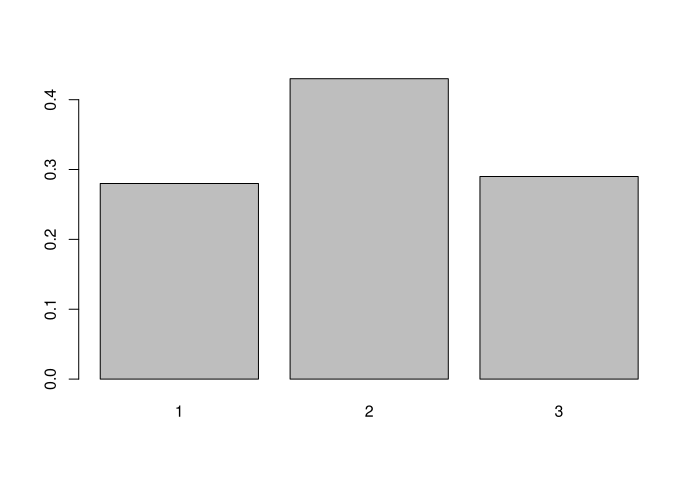

In [ ]:
%%R
barplot(table(direction)/length(direction))

### 33. Adding colours

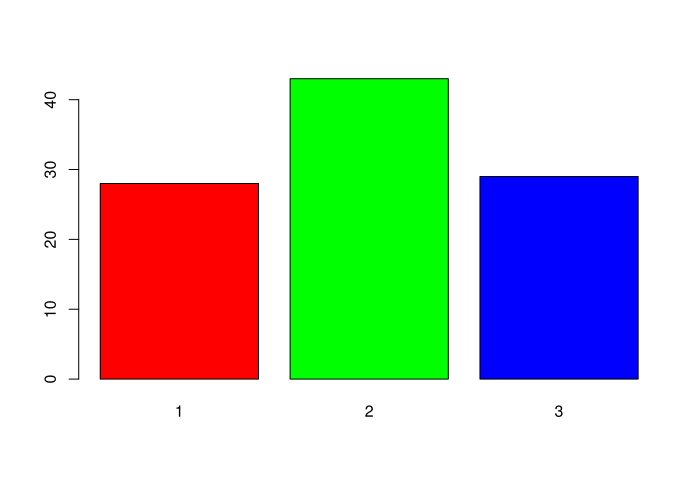

In [ ]:
%%R
barplot(table(direction), col=c("red", "green", "blue"))

### 34. Adding a title

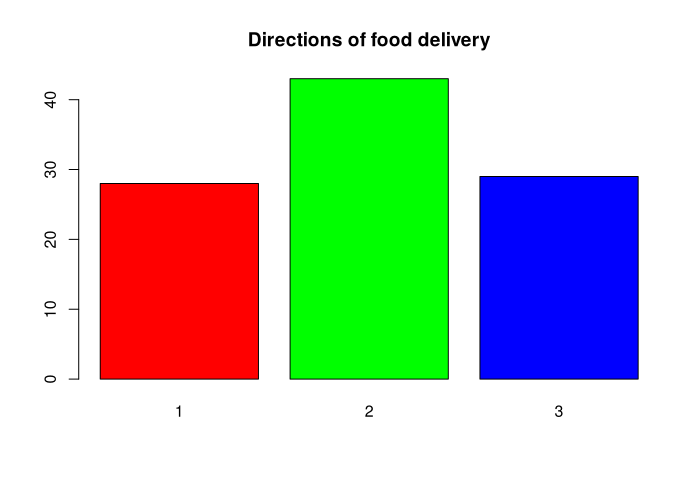

In [ ]:
%%R
barplot(table(direction), col=c("red", "green", "blue"),
        main="Directions of food delivery")

### 35. Adding a legend

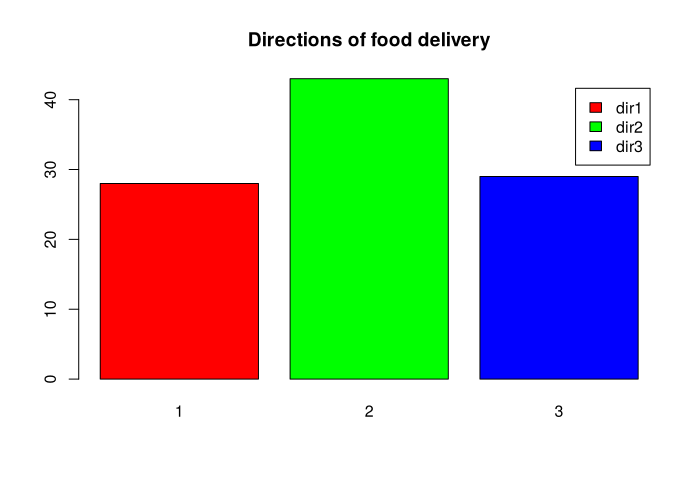

In [ ]:
%%R
barplot(table(direction), col=c("red", "green", "blue"),
        main="Directions of food delivery",
        legend.text=c("dir1", "dir2", "dir3"))

### 36. Adding a subtitle

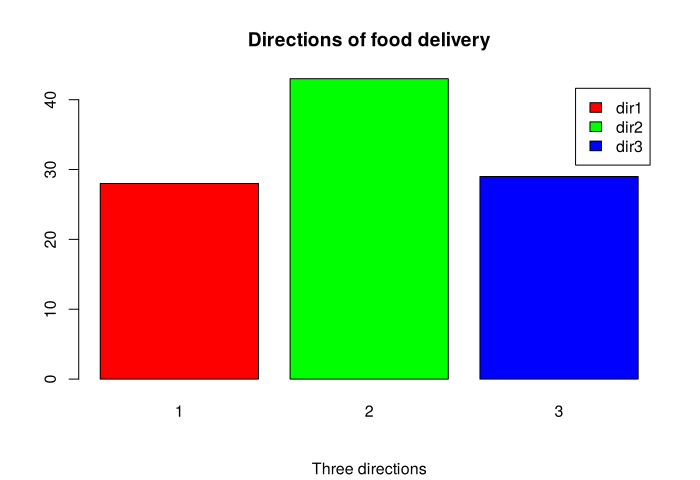

In [ ]:
%%R
barplot(table(direction), col=c("red", "green", "blue"),
        main="Directions of food delivery",
        legend.text=c("dir1", "dir2", "dir3"),
        sub="Three directions")

### 37. Axis labels with `xlab` and `ylab`

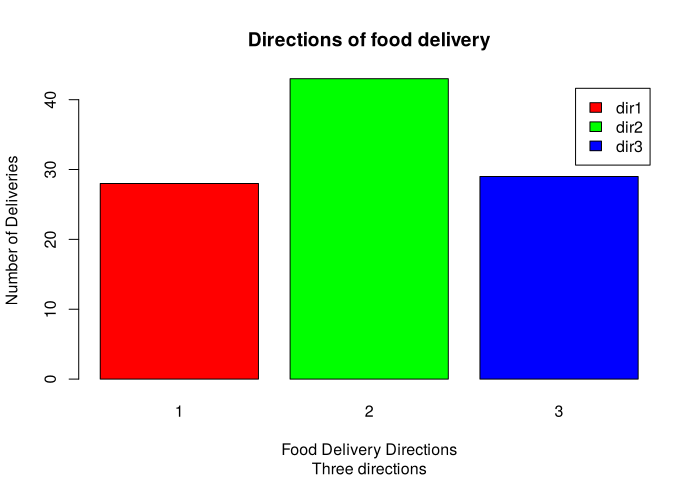

In [ ]:
%%R
barplot(table(direction), col=c("red", "green", "blue"),
        main="Directions of food delivery",
        legend.text=c("dir1", "dir2", "dir3"),
        sub="Three directions",
        xlab="Food Delivery Directions",
        ylab="Number of Deliveries")

---
## Quick reference

| Function | Purpose | Notes |
|---|---|---|
| `read_excel(f, sheet=, n_max=, range=)` | read Excel (`readxl`) | `range` accepts A1 or R1C1; first row of range = header |
| `read.spss()`, `read.dta()`, `read.xport()` | other software (`foreign`) | `to.data.frame=TRUE` for SPSS |
| `readHTMLTable(f)` | HTML tables (`XML`) | returns a list of data frames |
| `write(x, file, ncolumns, sep)` | write a vector | 5 numbers per line by default |
| `write.csv(df, file)` | CSV | adds a row-number column unless `row.names=FALSE` |
| `write.table(df, file, sep=, quote=)` | general delimited text | `file=""` prints to console |
| `table(x)` / `table(x)/length(x)` | absolute / relative frequencies | |
| `quantile(x, probs=)` | partition values | default = quartiles |
| `plot(x)` | scatter plot of values vs index | `col=` sets colour |
| `barplot(table(x))` | bar plot of category counts | `col`, `main`, `sub`, `xlab`, `ylab`, `legend.text` |

**The classic mistake:** `barplot(x)` draws one bar per *observation*; `barplot(table(x))` draws one bar per *category*.
